# Notebook 10 — Label-Efficiency Extension (1%, 5%)

**Muc tieu:** Mo rong thuc nghiem label-efficiency xuong muc du lieu rat thap
(1%, 5%) de xac dinh diem giao cat ma SSL bat dau vuot troi supervised baseline.

**Ly do:**
- NB07 (10%-100%): I-JEPA luon thua ResNet50, khong co diem giao cat
- Gia thuyet: O muc du lieu rat thap (1-5%), SSL co the vuot troi
  vi encoder da hoc duoc CXR features tu NIH ma khong can nhan

**Models:**
- I-JEPA Partial FT v1 (encoder NIH + fine-tune nhe, generalize tot hon)
- I-JEPA Full FT v2 (RSNA AUC cao nhat trong nhom I-JEPA)
- ResNet50 ImageNet (supervised baseline chinh)
- ViT-Small ImageNet (transformer baseline)

**Fractions:** [0.01, 0.05] + ket hop voi [0.10, 0.25, 0.50, 1.00] tu NB07
de ve duong crossover day du.

**Thiet ke:** Adapter strategy — I-JEPA load tu checkpoint da fine-tune,
ResNet50/ViT load tu ImageNet pretrained weights.
**Luu y:** 1% = 187 anh train, 5% = 934 anh — rat it, can nhieu seeds de on dinh.


In [1]:
# ============================================================
# CELL 1: IMPORTS VA CAU HINH
# ============================================================
import gc, json, random, shutil, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from PIL import Image
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T

try:
    import timm
except ImportError:
    import subprocess; subprocess.run(['pip','install','-q','timm'])
    import timm

try:
    import pydicom
except ImportError:
    import subprocess; subprocess.run(['pip','install','-q','pydicom'])
    import pydicom

import torchvision.models as tvm

DEVICE      = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
_AMP_DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('Device:', DEVICE)
if torch.cuda.is_available(): print('GPU:', torch.cuda.get_device_name(0))

INPUT_ROOT   = Path('/kaggle/input')
WORKING_ROOT = Path('/kaggle/working')
OUTPUT_DIR   = Path('/kaggle/working/notebook10_label_ext')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE      = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

NOTEBOOK_START = time.time()
SESSION_LIMIT  = 11.0 * 3600
print('Output:', OUTPUT_DIR)


Device: cuda
GPU: Tesla T4
Output: /kaggle/working/notebook10_label_ext


In [2]:
# ============================================================
# CELL 2: TIM INPUT FILES
# ============================================================
def find_file(filename):
    for root in [WORKING_ROOT, INPUT_ROOT]:
        matches = list(root.rglob(filename))
        if matches: return matches[0]
    return None

RSNA_TRAIN_CSV = find_file('rsna_train.csv')
RSNA_VAL_CSV   = find_file('rsna_val.csv')
RSNA_TEST_CSV  = find_file('rsna_test.csv')

IJEPA_PARTIAL_V1_CKPT = find_file('ijepa_partial_finetune_best.pth')
IJEPA_FULL_V2_CKPT    = find_file('ijepa_full_finetune_v2_best.pth')

print('RSNA Train:', RSNA_TRAIN_CSV)
print('RSNA Val  :', RSNA_VAL_CSV)
print('RSNA Test :', RSNA_TEST_CSV)
print('Partial v1:', IJEPA_PARTIAL_V1_CKPT)
print('Full v2   :', IJEPA_FULL_V2_CKPT)

assert RSNA_TRAIN_CSV and RSNA_VAL_CSV and RSNA_TEST_CSV
assert IJEPA_PARTIAL_V1_CKPT or IJEPA_FULL_V2_CKPT, 'Thieu I-JEPA checkpoint'


RSNA Train: /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_train.csv
RSNA Val  : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_val.csv
RSNA Test : /kaggle/input/notebooks/nguyentongphuc/01-eda-metadata-split-nih-rsna-vindr/metadata/rsna_test.csv
Partial v1: /kaggle/input/notebooks/nguyentongphuc/04-fine-tune-i-jepa-2/notebook04_ijepa_finetune/checkpoints/ijepa_partial_finetune_best.pth
Full v2   : /kaggle/input/notebooks/trnhuti666/04-fine-tune-i-jepa-4/notebook04_ijepa_finetune_v2/checkpoints/ijepa_full_finetune_v2_best.pth


In [3]:
# ============================================================
# CELL 3: DATASET + TRANSFORMS
# ============================================================
def fix_df_paths(df):
    def _fix(p):
        if Path(str(p)).exists(): return p
        matches = list(INPUT_ROOT.rglob(Path(str(p)).name))
        return str(matches[0]) if matches else None
    df = df.copy()
    df['image_path'] = df['image_path'].apply(_fix)
    return df.dropna(subset=['image_path']).reset_index(drop=True)

def read_image(path):
    p = str(path)
    if p.endswith('.dcm') or p.endswith('.dicom'):
        ds  = pydicom.dcmread(p)
        arr = ds.pixel_array.astype(np.float32)
        if str(getattr(ds,'PhotometricInterpretation','MONOCHROME2')).upper()=='MONOCHROME1':
            arr = arr.max() - arr
        mn, mx = arr.min(), arr.max()
        arr = ((arr - mn) / (mx - mn + 1e-8) * 255).astype(np.uint8)
        return Image.fromarray(arr).convert('RGB')
    return Image.open(p).convert('RGB')

train_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(0.5),
    T.RandomRotation(7),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transform = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class RSNADataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = read_image(row['image_path'])
        if self.transform: img = self.transform(img)
        return img, torch.tensor(float(row['label']), dtype=torch.float32)

print('Dataset helpers defined OK')


Dataset helpers defined OK


In [4]:
# ============================================================
# CELL 4: DOC RSNA + TINH POS_WEIGHT
# ============================================================
train_df = fix_df_paths(pd.read_csv(RSNA_TRAIN_CSV))
val_df   = fix_df_paths(pd.read_csv(RSNA_VAL_CSV))
test_df  = fix_df_paths(pd.read_csv(RSNA_TEST_CSV))

n_neg      = (train_df['label']==0).sum()
n_pos      = (train_df['label']==1).sum()
POS_WEIGHT = torch.tensor([n_neg / n_pos], dtype=torch.float32)

print(f'Train {len(train_df):,} | Val {len(val_df):,} | Test {len(test_df):,}')
print(f'POS_WEIGHT = {POS_WEIGHT.item():.4f} (neg={n_neg}, pos={n_pos})')

val_loader  = DataLoader(RSNADataset(val_df,  eval_transform),
                         batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(RSNADataset(test_df, eval_transform),
                         batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

# Tinh so luong mau thuc te cho tung fraction
LABEL_FRACTIONS_NEW = [0.01, 0.05]
LABEL_FRACTIONS_OLD = [0.10, 0.25, 0.50, 1.00]  # tu NB07
ALL_FRACTIONS       = LABEL_FRACTIONS_NEW + LABEL_FRACTIONS_OLD

print('\nSo luong anh train theo fraction:')
for frac in ALL_FRACTIONS:
    n = int(len(train_df) * frac)
    n_p = int(n_pos * frac)
    n_n = int(n_neg * frac)
    print(f'  {int(frac*100):4d}%  total={n:,}  pos={n_p}  neg={n_n}')


Train 18,678 | Val 4,003 | Test 4,003
POS_WEIGHT = 3.4387 (neg=14470, pos=4208)

So luong anh train theo fraction:
     1%  total=186  pos=42  neg=144
     5%  total=933  pos=210  neg=723
    10%  total=1,867  pos=420  neg=1447
    25%  total=4,669  pos=1052  neg=3617
    50%  total=9,339  pos=2104  neg=7235
   100%  total=18,678  pos=4208  neg=14470


In [5]:
# ============================================================
# CELL 5: MODEL CLASS + LOAD HELPERS
# ============================================================
class IJEPAClassifier(nn.Module):
    def __init__(self, encoder, embed_dim=384, dropout=0.2):
        super().__init__()
        self.encoder    = encoder
        self.classifier = nn.Sequential(
            nn.LayerNorm(embed_dim),
            nn.Dropout(dropout),
            nn.Linear(embed_dim, 1)
        )
    def forward(self, x):
        return self.classifier(self.encoder(x)).squeeze(1)

def load_ijepa_fresh(ckpt_path, dropout=0.2):
    enc   = timm.create_model('vit_small_patch16_224', pretrained=False, num_classes=0)
    model = IJEPAClassifier(enc, embed_dim=enc.num_features, dropout=dropout)
    try:    ck = torch.load(ckpt_path, map_location='cpu', weights_only=False)
    except TypeError: ck = torch.load(ckpt_path, map_location='cpu')
    model.load_state_dict(ck.get('model_state_dict', ck), strict=False)
    for p in model.parameters(): p.requires_grad = True
    return model.to(DEVICE)

@torch.no_grad()
def quick_auc(model, loader):
    model.eval()
    probs, lbls = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        with torch.amp.autocast(_AMP_DEVICE, enabled=torch.cuda.is_available()):
            logits = model(imgs)
        logits = logits.squeeze(-1) if logits.dim() > 1 else logits
        probs.extend(torch.sigmoid(logits).cpu().numpy())
        lbls.extend(labels.numpy())
    return roc_auc_score(np.array(lbls).astype(int), np.array(probs))

# ── FIX: Download weights 1 lần duy nhất bên ngoài vòng lặp ──
# ViT template — deepcopy trong vòng lặp thay vì download lại mỗi seed
import copy
print("Downloading ViT-Small ImageNet weights (1 lần)...")
_vit_template = timm.create_model(
    'vit_small_patch16_224', pretrained=True, num_classes=1
).cpu()
print("ViT-Small template OK")

# ResNet50 template
_r50_template = tvm.resnet50(weights='IMAGENET1K_V1')
_r50_template.fc = nn.Linear(_r50_template.fc.in_features, 1)
_r50_template = _r50_template.cpu()
print("ResNet50 template OK")

print('Model helpers defined OK')


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

ViT-Small template OK
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 174MB/s]


ResNet50 template OK
Model helpers defined OK


In [6]:
# ============================================================
# CELL 6: TRAIN_QUICK VAN DUNG NHIEU SEEDS
# ============================================================
# Config:
#   - 1%  fraction: 5 seeds, 20 epochs
#   - 5%  fraction: 3 seeds, 15 epochs
#   - 10%+:         1 seed,  15 epochs (nhu NB07)
# ============================================================

SEED_CONFIG = {
    0.01: {'seeds': [42, 123, 456, 789, 1234], 'epochs': 20},
    0.05: {'seeds': [42, 123, 456],              'epochs': 15},
    0.10: {'seeds': [42],                         'epochs': 15},
    0.25: {'seeds': [42],                         'epochs': 15},
    0.50: {'seeds': [42],                         'epochs': 15},
    1.00: {'seeds': [42],                         'epochs': 15},
}

IJEPA_HEAD_LR = 3e-5
# FIX: ở 1-5%, dùng enc_lr=None (chỉ train head) vì adapter strategy
# với 187 ảnh encoder hầu như không cần update
IJEPA_ENC_LR_LOW = None   # cho fraction <= 0.05
IJEPA_ENC_LR     = 3e-6   # cho fraction >= 0.10
R50_LR           = 1e-4
WD               = 0.05
ACCUM            = 2

def set_seed(s):
    random.seed(s); np.random.seed(s)
    torch.manual_seed(s); torch.cuda.manual_seed_all(s)

def train_quick(model, sub_df, num_epochs, head_lr, enc_lr=None, wd=0.05, accum=2):
    criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT.to(DEVICE))
    if enc_lr is not None and hasattr(model,'encoder') and hasattr(model,'classifier'):
        # Differential LR: encoder thấp, head cao
        param_groups = [
            {'params': [p for p in model.encoder.parameters()    if p.requires_grad], 'lr': enc_lr},
            {'params': [p for p in model.classifier.parameters() if p.requires_grad], 'lr': head_lr},
        ]
    elif enc_lr is None and hasattr(model,'encoder') and hasattr(model,'classifier'):
        # enc_lr=None → frozen encoder, chỉ train classifier head
        for p in model.encoder.parameters():
            p.requires_grad = False
        param_groups = [{'params': [p for p in model.classifier.parameters() if p.requires_grad], 'lr': head_lr}]
    else:
        # ResNet50 / ViT thông thường — train toàn bộ với head_lr
        param_groups = [{'params': [p for p in model.parameters() if p.requires_grad], 'lr': head_lr}]

    optimizer = torch.optim.AdamW(param_groups, weight_decay=wd)
    scaler    = torch.amp.GradScaler(_AMP_DEVICE, enabled=torch.cuda.is_available())
    loader    = DataLoader(RSNADataset(sub_df, train_transform),
                           batch_size=16, shuffle=True, num_workers=2, pin_memory=True)

    best_val_auc = -1
    for epoch in range(num_epochs):
        if time.time() - NOTEBOOK_START > SESSION_LIMIT:
            break
        model.train()
        optimizer.zero_grad(set_to_none=True)
        for step, (imgs, labels) in enumerate(loader):
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            with torch.amp.autocast(_AMP_DEVICE, enabled=torch.cuda.is_available()):
                logits = model(imgs)
                logits = logits.squeeze(-1) if logits.dim() > 1 else logits
                loss   = criterion(logits, labels) / accum
            scaler.scale(loss).backward()
            if (step + 1) % accum == 0:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(
                    [p for p in model.parameters() if p.requires_grad], 0.5)
                scaler.step(optimizer); scaler.update()
                optimizer.zero_grad(set_to_none=True)
        # Gradient flush cuối epoch
        if (step + 1) % accum != 0:
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(
                [p for p in model.parameters() if p.requires_grad], 0.5)
            scaler.step(optimizer); scaler.update()
            optimizer.zero_grad(set_to_none=True)
        val_auc = quick_auc(model, val_loader)
        if val_auc > best_val_auc: best_val_auc = val_auc
    return best_val_auc

print('train_quick() defined OK')
print('Seed config:')
for frac, cfg in SEED_CONFIG.items():
    enc_lr_str = 'None (head only)' if frac <= 0.05 else str(IJEPA_ENC_LR)
    print(f'  {int(frac*100):4d}%: {len(cfg["seeds"])} seeds x {cfg["epochs"]} epochs  enc_lr={enc_lr_str}')


train_quick() defined OK
Seed config:
     1%: 5 seeds x 20 epochs  enc_lr=None (head only)
     5%: 3 seeds x 15 epochs  enc_lr=None (head only)
    10%: 1 seeds x 15 epochs  enc_lr=3e-06
    25%: 1 seeds x 15 epochs  enc_lr=3e-06
    50%: 1 seeds x 15 epochs  enc_lr=3e-06
   100%: 1 seeds x 15 epochs  enc_lr=3e-06


## Chay Experiments

In [7]:
# ============================================================
# CELL 7: CHAY LABEL-EFFICIENCY 1% VA 5% + MULTI SEEDS
# ============================================================
results = []

print('=' * 60)
print('THIET KE: Adapter strategy')
print('  I-JEPA: load tu checkpoint da fine-tune RSNA')
print('  ResNet50/ViT: deepcopy tu template (khong download lai)')
print('=' * 60)

for frac in LABEL_FRACTIONS_NEW:
    cfg    = SEED_CONFIG[frac]
    seeds  = cfg['seeds']
    epochs = cfg['epochs']
    # FIX: enc_lr=None ở 1-5% (chỉ train head)
    ijepa_enc_lr = IJEPA_ENC_LR_LOW if frac <= 0.05 else IJEPA_ENC_LR

    elapsed_h = (time.time() - NOTEBOOK_START) / 3600
    if elapsed_h > 10.0:
        print(f'Time limit. Dung tai frac={frac}')
        break

    print(f'\n{"="*60}')
    print(f'{int(frac*100)}% labels ({int(len(train_df)*frac):,} samples)'
          f' | {len(seeds)} seeds x {epochs} epochs | enc_lr={ijepa_enc_lr}')
    print('=' * 60)

    for seed in seeds:
        set_seed(seed)
        pos_sub = train_df[train_df['label']==1].sample(frac=frac, random_state=seed)
        neg_sub = train_df[train_df['label']==0].sample(frac=frac, random_state=seed)
        sub_df  = pd.concat([pos_sub, neg_sub]).sample(
            frac=1, random_state=seed).reset_index(drop=True)

        print(f'\n  Seed={seed} | sub={len(sub_df):,}'
              f' (pos={len(pos_sub)}, neg={len(neg_sub)})')

        # I-JEPA Partial FT v1 — dropout=0.2 (NB04 v1 dùng 0.2)
        if IJEPA_PARTIAL_V1_CKPT:
            set_seed(seed)
            m = load_ijepa_fresh(IJEPA_PARTIAL_V1_CKPT, dropout=0.2)
            val_auc  = train_quick(m, sub_df, epochs, IJEPA_HEAD_LR, ijepa_enc_lr)
            test_auc = quick_auc(m, test_loader)
            results.append({'model':'I-JEPA Partial FT v1','fraction':frac,
                            'seed':seed,'n_train':len(sub_df),
                            'val_auc':round(val_auc,6),'test_auc':round(test_auc,6)})
            print(f'    I-JEPA Partial v1  val={val_auc:.4f}  test={test_auc:.4f}')
            del m; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

        # I-JEPA Full FT v2 — FIX: dropout=0.1 (NB04 v3 dùng 0.1, bukan 0.3)
        if IJEPA_FULL_V2_CKPT:
            set_seed(seed)
            m = load_ijepa_fresh(IJEPA_FULL_V2_CKPT, dropout=0.1)
            val_auc  = train_quick(m, sub_df, epochs, IJEPA_HEAD_LR, ijepa_enc_lr)
            test_auc = quick_auc(m, test_loader)
            results.append({'model':'I-JEPA Full FT v2','fraction':frac,
                            'seed':seed,'n_train':len(sub_df),
                            'val_auc':round(val_auc,6),'test_auc':round(test_auc,6)})
            print(f'    I-JEPA Full v2     val={val_auc:.4f}  test={test_auc:.4f}')
            del m; gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()

        # ResNet50 — FIX: deepcopy từ template, không download lại
        set_seed(seed)
        _r50 = copy.deepcopy(_r50_template).to(DEVICE)
        val_auc  = train_quick(_r50, sub_df, epochs, R50_LR, enc_lr=None)
        test_auc = quick_auc(_r50, test_loader)
        results.append({'model':'ResNet50 ImageNet','fraction':frac,
                        'seed':seed,'n_train':len(sub_df),
                        'val_auc':round(val_auc,6),'test_auc':round(test_auc,6)})
        print(f'    ResNet50           val={val_auc:.4f}  test={test_auc:.4f}')
        del _r50; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        # ViT-Small — FIX: deepcopy từ template, không download lại
        set_seed(seed)
        _vit = copy.deepcopy(_vit_template).to(DEVICE)
        val_auc  = train_quick(_vit, sub_df, epochs, R50_LR, enc_lr=None)
        test_auc = quick_auc(_vit, test_loader)
        results.append({'model':'ViT-Small ImageNet','fraction':frac,
                        'seed':seed,'n_train':len(sub_df),
                        'val_auc':round(val_auc,6),'test_auc':round(test_auc,6)})
        print(f'    ViT-Small          val={val_auc:.4f}  test={test_auc:.4f}')
        del _vit; gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

        # Lưu sau mỗi seed
        pd.DataFrame(results).to_csv(
            OUTPUT_DIR / 'label_eff_ext_results.csv', index=False)

print('\nDone! Saved: label_eff_ext_results.csv')
display(pd.DataFrame(results))


THIET KE: Adapter strategy
  I-JEPA: load tu checkpoint da fine-tune RSNA
  ResNet50/ViT: deepcopy tu template (khong download lai)

1% labels (186 samples) | 5 seeds x 20 epochs | enc_lr=None

  Seed=42 | sub=187 (pos=42, neg=145)
    I-JEPA Partial v1  val=0.8062  test=0.8000
    I-JEPA Full v2     val=0.8091  test=0.8041
    ResNet50           val=0.7963  test=0.7350
    ViT-Small          val=0.8161  test=0.7581

  Seed=123 | sub=187 (pos=42, neg=145)
    I-JEPA Partial v1  val=0.8062  test=0.8003
    I-JEPA Full v2     val=0.8092  test=0.8044
    ResNet50           val=0.8162  test=0.7850
    ViT-Small          val=0.8317  test=0.7872

  Seed=456 | sub=187 (pos=42, neg=145)
    I-JEPA Partial v1  val=0.8063  test=0.8004
    I-JEPA Full v2     val=0.8093  test=0.8043
    ResNet50           val=0.8169  test=0.7938
    ViT-Small          val=0.8254  test=0.8198

  Seed=789 | sub=187 (pos=42, neg=145)
    I-JEPA Partial v1  val=0.8063  test=0.8003
    I-JEPA Full v2     val=0.8092  te

,model,fraction,seed,n_train,val_auc,test_auc
0,I-JEPA Partial FT v1,0.01,42,187,0.806213,0.800036
1,I-JEPA Full FT v2,0.01,42,187,0.809066,0.804058
2,ResNet50 ImageNet,0.01,42,187,0.796263,0.735038
3,ViT-Small ImageNet,0.01,42,187,0.816132,0.758135
4,I-JEPA Partial FT v1,0.01,123,187,0.806218,0.800289
5,I-JEPA Full FT v2,0.01,123,187,0.809244,0.804397
6,ResNet50 ImageNet,0.01,123,187,0.816247,0.785031
7,ViT-Small ImageNet,0.01,123,187,0.831701,0.787182
8,I-JEPA Partial FT v1,0.01,456,187,0.806323,0.800355
9,I-JEPA Full FT v2,0.01,456,187,0.809326,0.804302


In [8]:
# ============================================================
# CELL 8: TINH MEAN +- STD THEO FRACTION
# ============================================================
results_df = pd.read_csv(OUTPUT_DIR / 'label_eff_ext_results.csv')

# Aggregate: mean +- std test_auc theo (model, fraction)
agg = results_df.groupby(['model','fraction']).agg(
    test_auc_mean=('test_auc','mean'),
    test_auc_std=('test_auc','std'),
    n_seeds=('seed','count')
).reset_index()
agg['test_auc_std'] = agg['test_auc_std'].fillna(0).round(4)
agg['test_auc_mean'] = agg['test_auc_mean'].round(4)
agg['ci'] = agg.apply(
    lambda r: f"{r['test_auc_mean']:.4f} +/- {r['test_auc_std']:.4f}", axis=1
)

# Them ket qua NB07 (10%-100%, seed=42) vao de so sanh day du
NB07_RESULTS = [
    {'model':'I-JEPA Full FT v2',  'fraction':0.10,'test_auc_mean':0.7861,'test_auc_std':0.0,'n_seeds':1,'ci':'0.7861 (NB07)'},
    {'model':'I-JEPA Full FT v2',  'fraction':0.25,'test_auc_mean':0.7930,'test_auc_std':0.0,'n_seeds':1,'ci':'0.7930 (NB07)'},
    {'model':'I-JEPA Full FT v2',  'fraction':0.50,'test_auc_mean':0.8039,'test_auc_std':0.0,'n_seeds':1,'ci':'0.8039 (NB07)'},
    {'model':'I-JEPA Full FT v2',  'fraction':1.00,'test_auc_mean':0.8136,'test_auc_std':0.0,'n_seeds':1,'ci':'0.8136 (NB07)'},
    {'model':'I-JEPA Partial FT v1','fraction':0.10,'test_auc_mean':0.7900,'test_auc_std':0.0,'n_seeds':1,'ci':'0.7900 (NB07)'},
    {'model':'I-JEPA Partial FT v1','fraction':0.25,'test_auc_mean':0.7980,'test_auc_std':0.0,'n_seeds':1,'ci':'0.7980 (NB07)'},
    {'model':'I-JEPA Partial FT v1','fraction':0.50,'test_auc_mean':0.7980,'test_auc_std':0.0,'n_seeds':1,'ci':'0.7980 (NB07)'},
    {'model':'I-JEPA Partial FT v1','fraction':1.00,'test_auc_mean':0.8100,'test_auc_std':0.0,'n_seeds':1,'ci':'0.8100 (NB07)'},
    {'model':'ResNet50 ImageNet','fraction':0.10,'test_auc_mean':0.8354,'test_auc_std':0.0,'n_seeds':1,'ci':'0.8354 (NB07)'},
    {'model':'ResNet50 ImageNet','fraction':0.25,'test_auc_mean':0.8331,'test_auc_std':0.0,'n_seeds':1,'ci':'0.8331 (NB07)'},
    {'model':'ResNet50 ImageNet','fraction':0.50,'test_auc_mean':0.8614,'test_auc_std':0.0,'n_seeds':1,'ci':'0.8614 (NB07)'},
    {'model':'ResNet50 ImageNet','fraction':1.00,'test_auc_mean':0.8816,'test_auc_std':0.0,'n_seeds':1,'ci':'0.8816 (NB07)'},
]

nb07_df   = pd.DataFrame(NB07_RESULTS)
combined  = pd.concat([agg, nb07_df], ignore_index=True)
combined  = combined.sort_values(['model','fraction']).reset_index(drop=True)
combined.to_csv(OUTPUT_DIR / 'label_eff_combined.csv', index=False)

print('=== BANG KET QUA DAY DU (1% den 100%) ===')
pivot = combined.pivot_table(
    index='model', columns='fraction', values='test_auc_mean'
).round(4)
pivot.columns = [f'{int(c*100)}%' for c in pivot.columns]
display(pivot)

print('\n=== MEAN +/- STD CHO 1% VA 5% ===')
display(agg[agg['fraction'].isin(LABEL_FRACTIONS_NEW)][
    ['model','fraction','n_seeds','ci']
].to_string(index=False))


=== BANG KET QUA DAY DU (1% den 100%) ===


,1%,5%,10%,25%,50%,100%
model,,,,,,
I-JEPA Full FT v2,0.8041,0.8041,0.7861,0.7930,0.8039,0.8136
I-JEPA Partial FT v1,0.8004,0.8001,0.7900,0.7980,0.7980,0.8100
ResNet50 ImageNet,0.7821,0.8170,0.8354,0.8331,0.8614,0.8816
ViT-Small ImageNet,0.7906,0.8185,NaN,NaN,NaN,NaN



=== MEAN +/- STD CHO 1% VA 5% ===


'               model  fraction  n_seeds                ci\n   I-JEPA Full FT v2      0.01        5 0.8041 +/- 0.0002\n   I-JEPA Full FT v2      0.05        3 0.8041 +/- 0.0004\nI-JEPA Partial FT v1      0.01        5 0.8004 +/- 0.0003\nI-JEPA Partial FT v1      0.05        3 0.8001 +/- 0.0001\n   ResNet50 ImageNet      0.01        5 0.7821 +/- 0.0286\n   ResNet50 ImageNet      0.05        3 0.8170 +/- 0.0160\n  ViT-Small ImageNet      0.01        5 0.7906 +/- 0.0250\n  ViT-Small ImageNet      0.05        3 0.8185 +/- 0.0215'

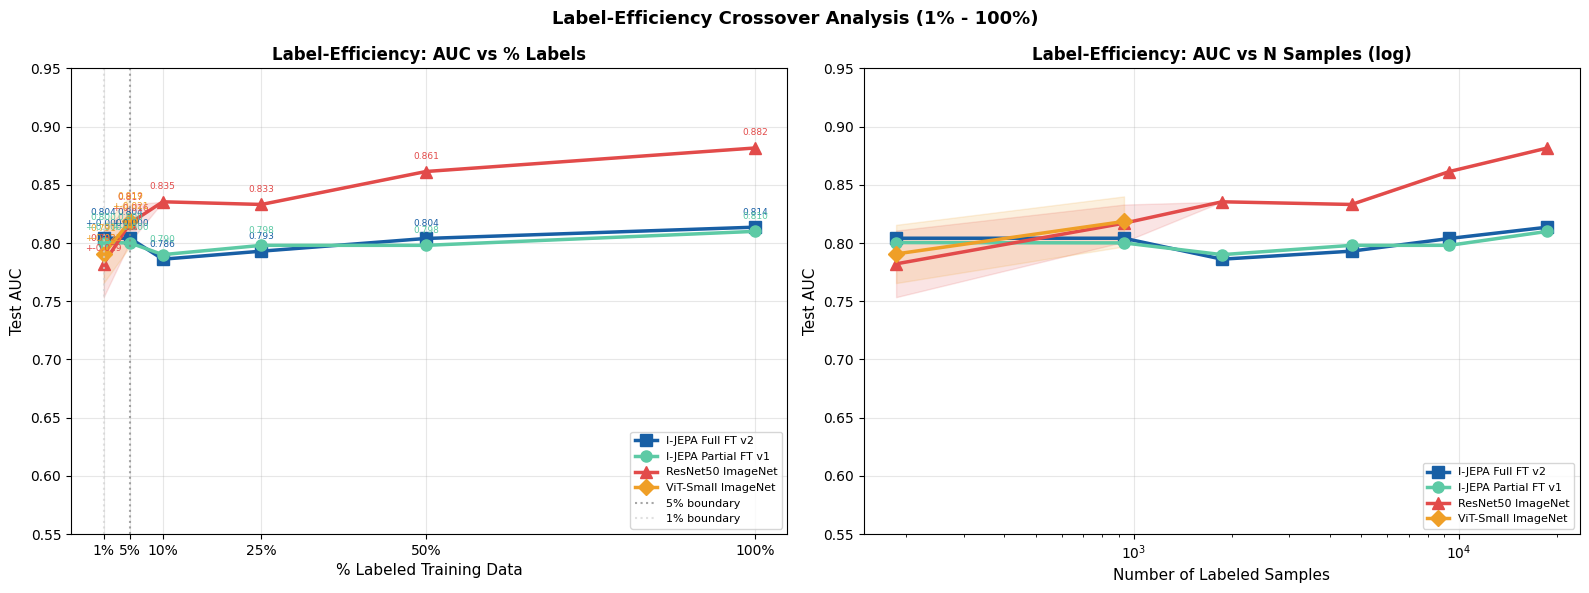

Saved: crossover_chart.png


In [9]:
# ============================================================
# CELL 9: DO THI CROSSOVER
# ============================================================
MODEL_COLORS = {
    'I-JEPA Partial FT v1': '#5DCAA5',
    'I-JEPA Full FT v2':    '#185FA5',
    'ResNet50 ImageNet':    '#E24B4A',
    'ViT-Small ImageNet':   '#EF9F27',
}
MODEL_MARKERS = {
    'I-JEPA Partial FT v1': 'o',
    'I-JEPA Full FT v2':    's',
    'ResNet50 ImageNet':    '^',
    'ViT-Small ImageNet':   'D',
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# X axis: so luong anh (log scale) va % (linear)
x_pcts  = [1, 5, 10, 25, 50, 100]
x_n     = [int(len(train_df) * f / 100) for f in x_pcts]

for model_name in combined['model'].unique():
    df_m   = combined[combined['model']==model_name].sort_values('fraction')
    color  = MODEL_COLORS.get(model_name, 'gray')
    marker = MODEL_MARKERS.get(model_name, 'o')

    fracs  = df_m['fraction'].values * 100  # percent
    means  = df_m['test_auc_mean'].values
    stds   = df_m['test_auc_std'].values

    # Panel 1: X = % label (linear)
    axes[0].plot(fracs, means, marker=marker, color=color,
                 lw=2.5, markersize=8, label=model_name)
    if stds.max() > 0:   # chỉ vẽ error band nếu có variance
        axes[0].fill_between(fracs, means - stds, means + stds,
                              alpha=0.15, color=color)
    for x, y, s in zip(fracs, means, stds):
        lbl = f'{y:.3f}' if s == 0 else f'{y:.3f}\n+-{s:.3f}'
        axes[0].annotate(lbl, (x, y), textcoords='offset points',
                          xytext=(0, 9), ha='center', fontsize=6.5,
                          color=color)

    # Panel 2: X = so luong anh (log scale)
    n_samples = [int(len(train_df) * f) for f in df_m['fraction'].values]
    axes[1].plot(n_samples, means, marker=marker, color=color,
                 lw=2.5, markersize=8, label=model_name)
    if stds.max() > 0:
        axes[1].fill_between(n_samples, means - stds, means + stds,
                              alpha=0.15, color=color)

# Crossover annotation
axes[0].axvline(x=5, color='gray', linestyle=':', lw=1.5, alpha=0.7,
                label='5% boundary')
axes[0].axvline(x=1, color='lightgray', linestyle=':', lw=1.5, alpha=0.7,
                label='1% boundary')

for ax, xlabel, title, xscale in [
    (axes[0], '% Labeled Training Data', 'Label-Efficiency: AUC vs % Labels', 'linear'),
    (axes[1], 'Number of Labeled Samples', 'Label-Efficiency: AUC vs N Samples (log)', 'log'),
]:
    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel('Test AUC', fontsize=11)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xscale(xscale)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(0.55, 0.95)

axes[0].set_xticks([1, 5, 10, 25, 50, 100])
axes[0].set_xticklabels(['1%','5%','10%','25%','50%','100%'])

plt.suptitle('Label-Efficiency Crossover Analysis (1% - 100%)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'crossover_chart.png', dpi=200, bbox_inches='tight')
plt.show()
print('Saved: crossover_chart.png')


In [10]:
# ============================================================
# CELL 10: PHAN TICH CROSSOVER POINT
# ============================================================
print('=== PHAN TICH DIEM GIAO CAT ===')
print()

# Voi moi cap I-JEPA vs baseline, tim fraction ma I-JEPA bat dau thua
baselines = ['ResNet50 ImageNet', 'ViT-Small ImageNet']
ijepa_models = ['I-JEPA Partial FT v1', 'I-JEPA Full FT v2']

all_fracs_sorted = sorted(combined['fraction'].unique())

for ijepa_name in ijepa_models:
    for base_name in baselines:
        ijepa_row = combined[combined['model']==ijepa_name].set_index('fraction')
        base_row  = combined[combined['model']==base_name].set_index('fraction')

        if len(ijepa_row) == 0 or len(base_row) == 0:
            continue

        common_fracs = sorted(set(ijepa_row.index) & set(base_row.index))
        if not common_fracs:
            continue

        print(f'--- {ijepa_name} vs {base_name} ---')
        crossover_found = False
        for f in common_fracs:
            i_auc = ijepa_row.loc[f, 'test_auc_mean']
            b_auc = base_row.loc[f,  'test_auc_mean']
            diff  = i_auc - b_auc
            n_samp = int(len(train_df) * f)
            status = 'I-JEPA BETTER (+)' if diff > 0 else 'Baseline better (-)'
            print(f'  {int(f*100):4d}% ({n_samp:5,} samples)  '
                  f'I-JEPA={i_auc:.4f}  {base_name.split()[0]}={b_auc:.4f}  '
                  f'diff={diff:+.4f}  {status}')
            if diff > 0 and not crossover_found:
                crossover_found = True
                print(f'  >>> CROSSOVER POINT: I-JEPA vượt trội tại {int(f*100)}%'
                      f' ({n_samp:,} samples) <<<')

        if not crossover_found:
            print(f'  >> Khong tim thay crossover: I-JEPA luon thua {base_name}')
            min_gap = min(ijepa_row.loc[f,'test_auc_mean'] - base_row.loc[f,'test_auc_mean']
                          for f in common_fracs)
            print(f'     Khoang cach nho nhat: {min_gap:+.4f}')
        print()


=== PHAN TICH DIEM GIAO CAT ===

--- I-JEPA Partial FT v1 vs ResNet50 ImageNet ---
     1% (  186 samples)  I-JEPA=0.8004  ResNet50=0.7821  diff=+0.0183  I-JEPA BETTER (+)
  >>> CROSSOVER POINT: I-JEPA vượt trội tại 1% (186 samples) <<<
     5% (  933 samples)  I-JEPA=0.8001  ResNet50=0.8170  diff=-0.0169  Baseline better (-)
    10% (1,867 samples)  I-JEPA=0.7900  ResNet50=0.8354  diff=-0.0454  Baseline better (-)
    25% (4,669 samples)  I-JEPA=0.7980  ResNet50=0.8331  diff=-0.0351  Baseline better (-)
    50% (9,339 samples)  I-JEPA=0.7980  ResNet50=0.8614  diff=-0.0634  Baseline better (-)
   100% (18,678 samples)  I-JEPA=0.8100  ResNet50=0.8816  diff=-0.0716  Baseline better (-)

--- I-JEPA Partial FT v1 vs ViT-Small ImageNet ---
     1% (  186 samples)  I-JEPA=0.8004  ViT-Small=0.7906  diff=+0.0098  I-JEPA BETTER (+)
  >>> CROSSOVER POINT: I-JEPA vượt trội tại 1% (186 samples) <<<
     5% (  933 samples)  I-JEPA=0.8001  ViT-Small=0.8185  diff=-0.0184  Baseline better (-)

--- I-J

In [11]:
# ============================================================
# CELL 11: LUU OUTPUT
# ============================================================
# Final combined table
combined.to_csv(OUTPUT_DIR / 'label_eff_combined_full.csv', index=False)

summary = {
    'fractions_new':    LABEL_FRACTIONS_NEW,
    'fractions_old':    LABEL_FRACTIONS_OLD,
    'seed_config':      {str(k): v for k, v in SEED_CONFIG.items()},
    'ijepa_head_lr':    IJEPA_HEAD_LR,
    'ijepa_enc_lr':     IJEPA_ENC_LR,
    'r50_lr':           R50_LR,
}
with open(OUTPUT_DIR / 'config.json', 'w') as f:
    json.dump(summary, f, indent=2)

print('Files trong output:')
for p in sorted(OUTPUT_DIR.rglob('*')):
    if p.is_file():
        print(f'  {str(p.relative_to(OUTPUT_DIR)):50s}  ({p.stat().st_size/1e3:.1f} KB)')

shutil.make_archive('/kaggle/working/notebook10_label_ext', 'zip', OUTPUT_DIR)
print('\nCreated: notebook10_label_ext.zip')
print(f'Tong thoi gian: {(time.time()-NOTEBOOK_START)/3600:.2f}h')


Files trong output:
  config.json                                         (0.7 KB)
  crossover_chart.png                                 (239.1 KB)
  label_eff_combined.csv                              (1.1 KB)
  label_eff_combined_full.csv                         (1.1 KB)
  label_eff_ext_results.csv                           (1.6 KB)

Created: notebook10_label_ext.zip
Tong thoi gian: 7.06h
